#### Import and Helpers

In [1]:
import sys, json
from time import perf_counter
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
from transformers import AutoTokenizer

sys.path.append(str(Path("..").resolve()))
from dataset.statistics import read_split, generate_report

/home/imrui/miniforge3/envs/tornith/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def load_stats(ds_dir):
    fp = Path(ds_dir) / "statistic.json"
    if not fp.exists():
        generate_report(ds_dir)
    return json.loads(fp.read_text())

def match(meta, flt):
    if not flt:
        return True
    for k, allowed in flt.items():
        v = meta.get(k)
        allowed = allowed if isinstance(allowed, (list, tuple, set)) else [allowed]
        hit = any(x in allowed for x in v) if isinstance(v, list) else v in allowed
        if not hit:
            return False
    return True

# All Dataset Overview

Scan every CPT/SFT dataset and compare its size and structural distribution. Set `APPROX_TOKEN = True` for the fast `characters / 4` estimate, or `False` to use the Ornith tokenizer and apply its chat template to SFT messages.

In [3]:
DATASET_ROOT    = Path("../../dataset")
TOKENIZER_NAME  = "ornith-ai/Ornith-1.5-9B"
APPROX_TOKEN    = True
MAX_SEQ_LENGTH  = 4096
TOKEN_BATCH_SIZE = 256

In [4]:
tokenizer = (
    AutoTokenizer.from_pretrained(TOKENIZER_NAME)
    if not APPROX_TOKEN else None
)

def training_text(record, stage):
    if stage == "cpt":
        return record.get("text", "") + ((tokenizer.eos_token or "") if tokenizer else "")
    messages = record.get("messages", [])
    if tokenizer:
        return tokenizer.apply_chat_template(
            messages, tokenize=False, add_generation_prompt=False,
        )
    return "\n".join(
        message.get("content", message.get("context", ""))
        for message in messages if isinstance(message, dict)
    )

def token_lengths(texts):
    if not tokenizer:
        return [round(len(text) / 4) for text in texts]
    lengths = []
    for start in range(0, len(texts), TOKEN_BATCH_SIZE):
        batch = texts[start:start + TOKEN_BATCH_SIZE]
        encoded = tokenizer(
            batch, add_special_tokens=False, truncation=False,
        )["input_ids"]
        lengths.extend(len(ids) for ids in encoded)
    return lengths

def percentile(values, fraction):
    if not values:
        return 0
    ordered = sorted(values)
    return ordered[round((len(ordered) - 1) * fraction)]

In [5]:
started = perf_counter()
overview = []
dataset_dirs = sorted({fp.parent for fp in DATASET_ROOT.glob("**/*.jsonl") if fp.name in {"train.jsonl", "valid.jsonl"}})

for ds_dir in dataset_dirs:
    relative = ds_dir.relative_to(DATASET_ROOT).parts
    stage = relative[0]
    if stage not in {"cpt", "sft"}:
        continue
    task = "cpt" if stage == "cpt" else relative[1]
    stats = load_stats(ds_dir)
    texts = [
        training_text(record, stage)
        for split in ("train", "valid")
        for record in read_split(ds_dir, split)
    ]
    lengths = token_lengths(texts)
    classes = {
        name: sum(stats[split]["property"]["class"].get(name, 0) for split in ("train", "valid"))
        for name in ("function", "graph", "osp", "fullstack")
    }
    overview.append({
        "Stage": stage.upper(),
        "Task type": task,
        "Dataset": ds_dir.name,
        "# Train": stats["train"]["count"],
        "# Valid": stats["valid"]["count"],
        "Total tokens": sum(lengths),
        "Avg. #tokens": round(sum(lengths) / len(lengths), 1) if lengths else 0,
        "P95 tokens": percentile(lengths, 0.95),
        f"> {MAX_SEQ_LENGTH}": sum(length > MAX_SEQ_LENGTH for length in lengths),
        "Function": classes["function"],
        "Graph": classes["graph"],
        "OSP": classes["osp"],
        "Fullstack": classes["fullstack"],
    })

overview_df = pd.DataFrame(overview).sort_values(["Stage", "Task type", "Dataset"])
mode = "estimate: characters / 4" if APPROX_TOKEN else f"exact: {TOKENIZER_NAME}"
print(f"Token mode: {mode} | datasets: {len(overview_df)} | elapsed: {perf_counter() - started:.2f}s")
display(overview_df.style.format({"Total tokens": "{:,}", "Avg. #tokens": "{:,.1f}", "P95 tokens": "{:,}"}))

Token mode: exact: ornith-ai/Ornith-1.5-9B | datasets: 11 | elapsed: 3.81s


,Stage,Task type,Dataset,# Train,# Valid,Total tokens,Avg. #tokens,P95 tokens,> 4096,Function,Graph,OSP,Fullstack
0,CPT,cpt,Ayush-ground-truth,544,102,"2,665,787","4,126.6","4,442",570,0,0,0,0
1,CPT,cpt,Nitin-4repo-cpt,119,0,"333,861","2,805.6","4,850",9,49,7,13,50
2,CPT,cpt,Nitin-9k-py2jac-idiom,8615,0,"1,099,065",127.6,274,0,8615,0,0,0
3,CPT,cpt,Nitin-jachack-all,895,0,"924,715","1,033.2","3,795",39,502,185,137,71
4,SFT,code_gen,opus-synth-v2,1841,460,"1,252,844",544.5,"1,915",30,774,456,676,395
5,SFT,farm,Nitin-2k-farm,1385,346,"1,208,429",698.1,"2,083",1,1731,0,0,0
6,SFT,js2jac,Nitin-10k-js2jac-idiom,2402,600,"2,355,600",784.7,"2,140",10,1678,0,1,1323
7,SFT,osp,Nitin-1k-osp,828,206,"728,401",704.4,"2,452",0,0,0,1034,0
8,SFT,py2jac,opus-synth-v2,400,93,"110,110",223.3,436,0,417,0,76,0
9,SFT,qa,opus-synth-v2,4292,1072,"2,059,451",383.9,"1,282",29,0,0,0,0


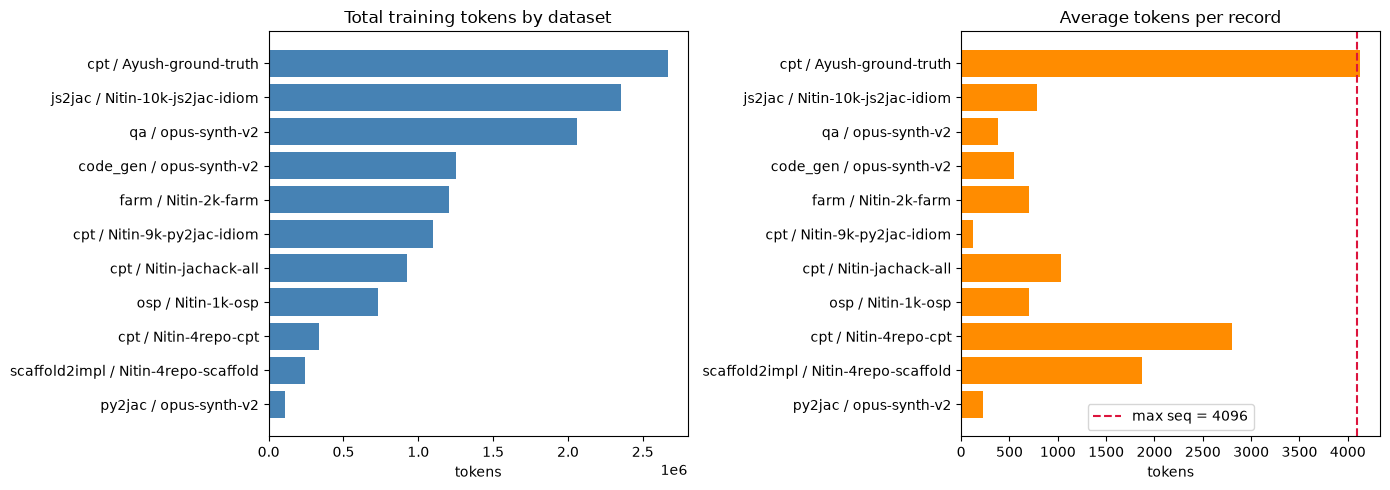

In [ ]:
plot_df = overview_df.sort_values("Total tokens")
labels = plot_df["Task type"] + " / " + plot_df["Dataset"]
fig, axes = plt.subplots(1, 2, figsize=(14, max(5, len(plot_df) * 0.45)))
axes[0].barh(labels, plo t_df["Total tokens"], color="steelblue")
axes[0].set_title("Total training tokens by dataset")
axes[0].set_xlabel("tokens")
axes[1].barh(labels, plot_df["Avg. #tokens"], color="darkorange")
axes[1].axvline(MAX_SEQ_LENGTH, color="crimson", linestyle="--", label=f"max seq = {MAX_SEQ_LENGTH}")
axes[1].set_title("Average tokens per record")
axes[1].set_xlabel("tokens")
axes[1].legend()
plt.tight_layout()
plt.show()

# Dataset Dashboard
1. Given dataset, display the data in prettier look (\n displayed as real newline etc)
2. Costumized filter that helps us fine the useful info

In [7]:
DATA_DIR  = "../../dataset/sft/code_completion/Nitin-10k-jac-functions"
SPLIT     = ["train", "valid"]
FORMAT    = "jsonl"


# Preview

In [8]:
N_DISPLAY = 3
FILTER    = None  # None or {} = show all; otherwise {"class": ["graph"]} etc.


In [9]:
def render(rec):
    """Return a readable string for either a CPT ({"text": ...}) or SFT
    ({"messages": [...]}) record."""
    if isinstance(rec.get("text"), str):
        return rec["text"]
    parts = []
    for m in rec.get("messages", []):
        role = m.get("role", "?")
        content = m.get("content", m.get("context", ""))
        parts.append(f"[{role}]\n{content}")
    return "\n\n".join(parts)

for split in SPLIT:
    print("=" * 80)
    print(f"SPLIT: {split}")
    print("=" * 80)
    shown = matched = 0
    for rec in read_split(DATA_DIR, split):
        if not match(rec.get("meta", {}), FILTER):
            continue
        matched += 1
        if shown < N_DISPLAY:
            shown += 1
            print(f"\n--- [{split} #{shown}] meta={rec.get('meta', {})} ---")
            print(render(rec))
    print(f"\n>>> {split}: {matched} record(s) matched {FILTER}; displayed {shown}\n")


SPLIT: train

>>> train: 0 record(s) matched None; displayed 0

SPLIT: valid

>>> valid: 0 record(s) matched None; displayed 0



# Statistics

In [10]:
BAR   = ["class"] # columns you want to plot as a bar chart, in SFT "task_type" is worth seeing

In [11]:
stats = load_stats(DATA_DIR)

n_rows = len(SPLIT)
n_cols = len(BAR) + 1  # +1 for length histogram
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 3.5 * n_rows), squeeze=False)

for i, split in enumerate(SPLIT):
    props = stats[split]["property"]
    for j, field in enumerate(BAR):
        ax = axes[i][j]
        items = sorted(props[field].items(), key=lambda kv: -kv[1])
        labels, values = zip(*items) if items else ([], [])
        bars = ax.bar(labels, values, color="steelblue")
        ax.set_title(f"{split} — {field}  (n={stats[split]['count']})")
        ax.set_ylabel("count")
        ax.tick_params(axis="x", rotation=30)
        for b, v in zip(bars, values):
            ax.text(b.get_x() + b.get_width() / 2, v, str(v),
                    ha="center", va="bottom", fontsize=8)

    ax = axes[i][-1]
    hist = stats[split].get("histogram", {})
    labels, values = list(hist.keys()), list(hist.values())
    bars = ax.bar(labels, values, color="darkorange")
    length = stats[split]["length"]
    ax.set_title(f"{split} — length (chars)  avg={length['avg']}  med={length['median']}")
    ax.set_ylabel("count")
    ax.tick_params(axis="x", rotation=30)
    for b, v in zip(bars, values):
        ax.text(b.get_x() + b.get_width() / 2, v, str(v),
                ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.show()


NotADirectoryError: Dataset directory not found: ../../dataset/sft/code_completion/Nitin-10k-jac-functions